In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.momentum import RSIIndicator
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("Libraries loaded")

Libraries loaded


In [7]:
import sys
!{sys.executable} -m pip install matplotlib seaborn

In [12]:
tickers = ['MRK', 'MS', 'NVDA', 'MU', 'QQQ']   # adjusted based on your image
data = yf.download(tickers, start='2010-01-01', end='2020-06-30', group_by='ticker')

stock = 'NVDA'
df = data[stock].copy()
df = df[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
df.head()

[*********************100%***********************]  5 of 5 completed


Price,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,0.424242,0.426763,0.415074,0.423784,800204000
2010-01-05,0.422179,0.434556,0.422179,0.429972,728648000
2010-01-06,0.429743,0.433639,0.425617,0.432722,649168000
2010-01-07,0.430430,0.432264,0.421033,0.424242,547792000
2010-01-08,0.420804,0.428139,0.418283,0.425159,478168000


In [13]:
df['SMA_20'] = SMAIndicator(close=df['Close'], window=20).sma_indicator()
df['SMA_50'] = SMAIndicator(close=df['Close'], window=50).sma_indicator()
df['EMA_12'] = EMAIndicator(close=df['Close'], window=12).ema_indicator()
df['EMA_26'] = EMAIndicator(close=df['Close'], window=26).ema_indicator()
df['RSI'] = RSIIndicator(close=df['Close'], window=14).rsi()

macd = MACD(close=df['Close'], window_slow=26, window_fast=12, window_sign=9)
df['MACD'] = macd.macd()
df['MACD_signal'] = macd.macd_signal()
df['MACD_diff'] = macd.macd_diff()

df.tail()

Price,Open,High,Low,Close,Volume,SMA_20,SMA_50,EMA_12,EMA_26,RSI,MACD,MACD_signal,MACD_diff
Date,,,,,,,,,,,,,
2020-06-23,9.518040,9.609225,9.375036,9.417389,375108000,8.960578,8.195571,9.144489,8.818502,63.839671,0.325986,0.330718,-0.004732
2020-06-24,9.443548,9.523522,9.112943,9.203629,449372000,8.996162,8.238223,9.153587,8.847030,58.301772,0.306557,0.325886,-0.019329
2020-06-25,9.323465,9.472200,9.150564,9.457252,376072000,9.046332,8.287497,9.200305,8.892232,62.462473,0.308073,0.322323,-0.014250
2020-06-26,9.467217,9.467217,9.093511,9.123407,592084000,9.060460,8.323190,9.188474,8.909356,54.722236,0.279119,0.313682,-0.034564
2020-06-29,9.138106,9.172736,8.869286,9.168251,342248000,9.080280,8.360966,9.185363,8.928533,55.519581,0.256830,0.302312,-0.045482


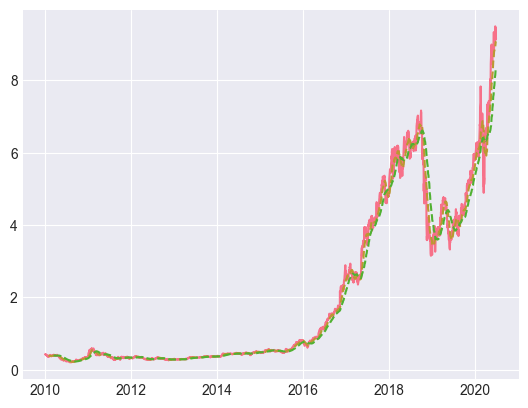

In [16]:
#Plot price with moving averages
plt.plot(df.index, df['Close'], label='Close Price')
plt.plot(df.index, df['SMA_20'], label='SMA 20', linestyle='--')
plt.plot(df.index, df['SMA_50'], label='SMA 50', linestyle='--')

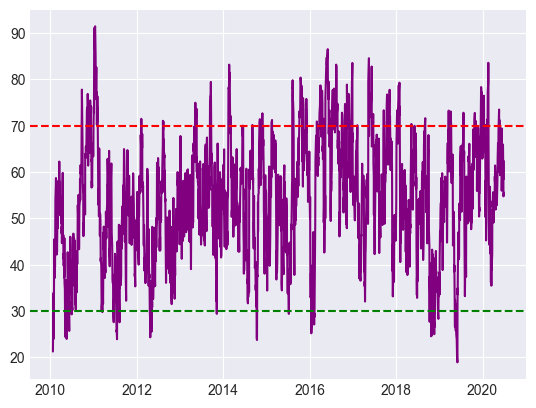

In [17]:
#Plot RSI

plt.plot(df.index, df['RSI'], color='purple')
plt.axhline(70, linestyle='--', color='red')  # overbought line
plt.axhline(30, linestyle='--', color='green') # oversold line

<BarContainer object of 2640 artists>

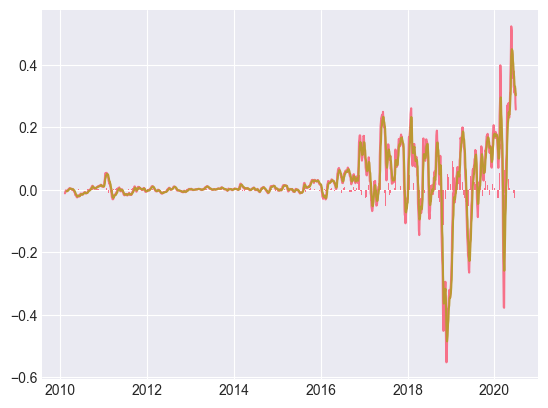

In [18]:
plt.plot(df.index, df['MACD'], label='MACD')
plt.plot(df.index, df['MACD_signal'], label='Signal')
plt.bar(df.index, df['MACD_diff'], label='Histogram')

In [21]:
for ticker in tickers:
    temp = data[ticker].copy()
    temp = temp[['Close']].dropna()
    temp['SMA_20'] = SMAIndicator(close=temp['Close'], window=20).sma_indicator()
    temp['RSI'] = RSIIndicator(close=temp['Close'], window=14).rsi()
    last_close = temp['Close'].iloc[-1]
    last_sma = temp['SMA_20'].iloc[-1]
    last_rsi = temp['RSI'].iloc[-1]
    position = 'Above' if last_close > last_sma else 'Below'
    print(f"{ticker}: Close = {last_close:.2f}, SMA20 = {last_sma:.2f} ({position}), RSI = {last_rsi:.1f}")

MRK: Close = 60.59, SMA20 = 62.14 (Below), RSI = 45.6
MS: Close = 39.27, SMA20 = 39.67 (Below), RSI = 54.0
NVDA: Close = 9.17, SMA20 = 9.08 (Above), RSI = 55.5
MU: Close = 47.94, SMA20 = 49.05 (Below), RSI = 50.1
QQQ: Close = 234.94, SMA20 = 233.36 (Above), RSI = 56.7


## Task 2: Technical Indicators – Summary

We downloaded historical daily price data for the top 5 stocks from Task 1 (MRK, MS, NVDA, MU, QQQ) using `yfinance` (period 2010‑01‑01 to 2020‑06‑30). For detailed analysis we focused on **NVDA**.

Using the `ta` library, we computed:

- Simple Moving Averages (SMA): 20‑day and 50‑day
- Exponential Moving Averages (EMA)**: 12‑day and 26‑day
- Relative Strength Index (RSI): 14‑day
- MACD (fast=12, slow=26, signal=9)

# Key Observations
- The SMA_20 and SMA_50 plots show the long‑term trend. When the price stays above both SMAs, it indicates a strong uptrend (NVDA exhibited this during 2016‑2020).
- The RSI stayed mostly between 30 and 70, suggesting no extreme overbought/oversold conditions during the sampled period, though brief spikes near 70 occurred around momentum peaks.
- The MACD histogram turned positive during upward price moves, confirming bullish momentum.

These indicators will serve as a baseline in Task 3 when we overlay news sentiment to see if sentiment adds predictive power beyond pure price action.